In [36]:
# Superstore Sales Intelligence System

### Author: Fatima Azeemi

## Project Objective
## Analyze sales performance, profit trends, customer behavior, and business insights using Data Analytics and Machine Learning.

## Business Goal
## Help management make data-driven decisions by identifying profitable products, regions, customer segments, and predicting future profit.

###**Import Libraries**

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

###**Load Dataset**

In [38]:
# Data Loading

In [39]:
df = pd.read_csv("Superstore.csv", encoding='latin1')

In [40]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


###**Dataset Overview**

In [41]:
# Dataset Understanding

In [42]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [44]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [45]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


###**Data Cleaning**

In [46]:
# Data Cleaning

###**Duplicate Check**

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.drop_duplicates(inplace=True)

###**Missing Values**

In [49]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [50]:
df.dropna(inplace=True)

###**Date Conversion**

In [51]:
# Date Processing

In [52]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

###**Feature Engineering**

In [53]:
# Feature Engineering

###**Month**

In [54]:
df['Month'] = df['Order Date'].dt.month

###**Year**

In [55]:
df['Year'] = df['Order Date'].dt.year

###**Profit Margin**

In [56]:
df['Profit Margin'] = (
    df['Profit'] /
    df['Sales']
) * 100

In [57]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,11.25


###**Exploratory Data Analysis (EDA)**

In [58]:
# Exploratory Data Analysis

###**Monthly Sales Trend**

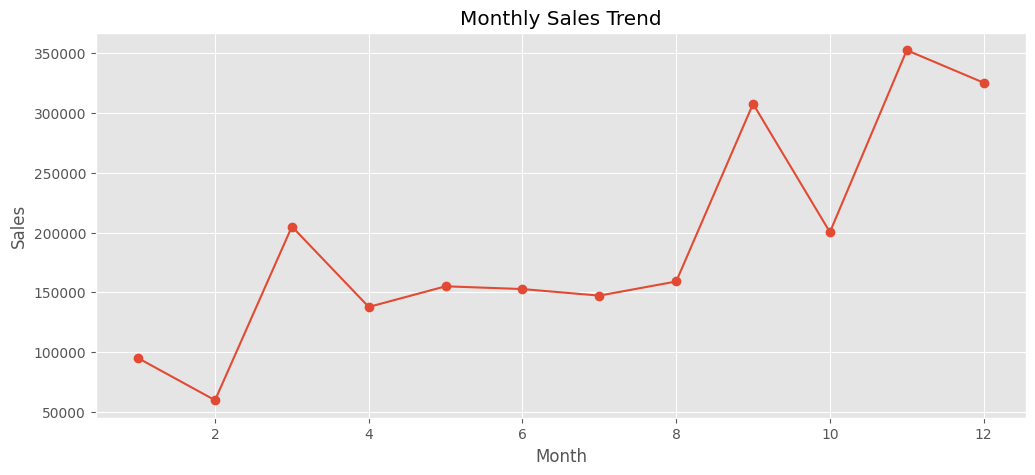

In [59]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

###**Yearly Sales Performance**

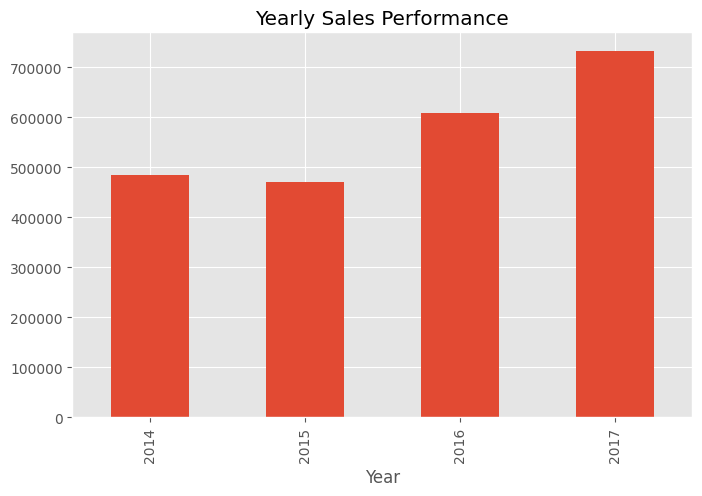

In [60]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))

yearly_sales.plot(kind='bar')

plt.title("Yearly Sales Performance")
plt.show()

###**Top 10 Products by Sales**

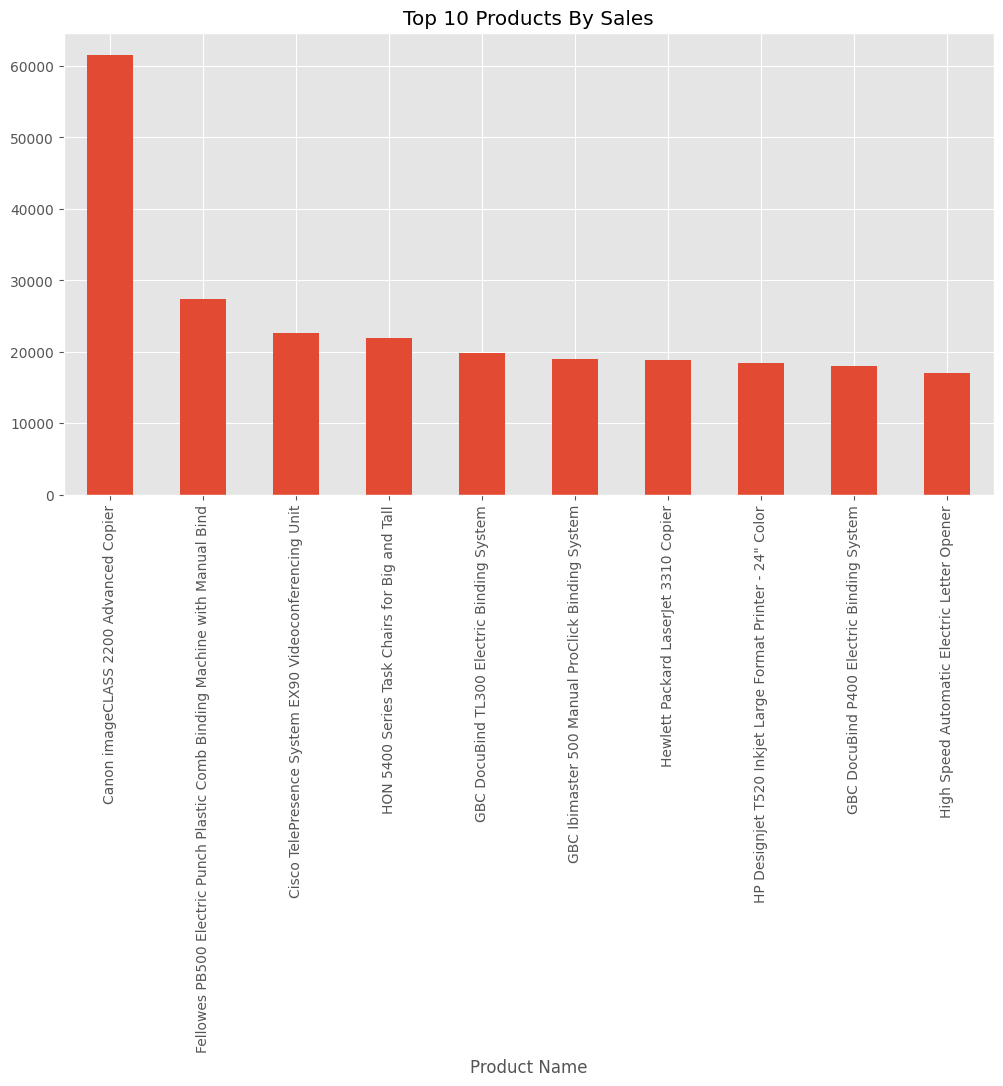

In [61]:
top_sales_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_sales_products.plot(kind='bar')

plt.title("Top 10 Products By Sales")
plt.show()

###**Top 10 Products by Profit**

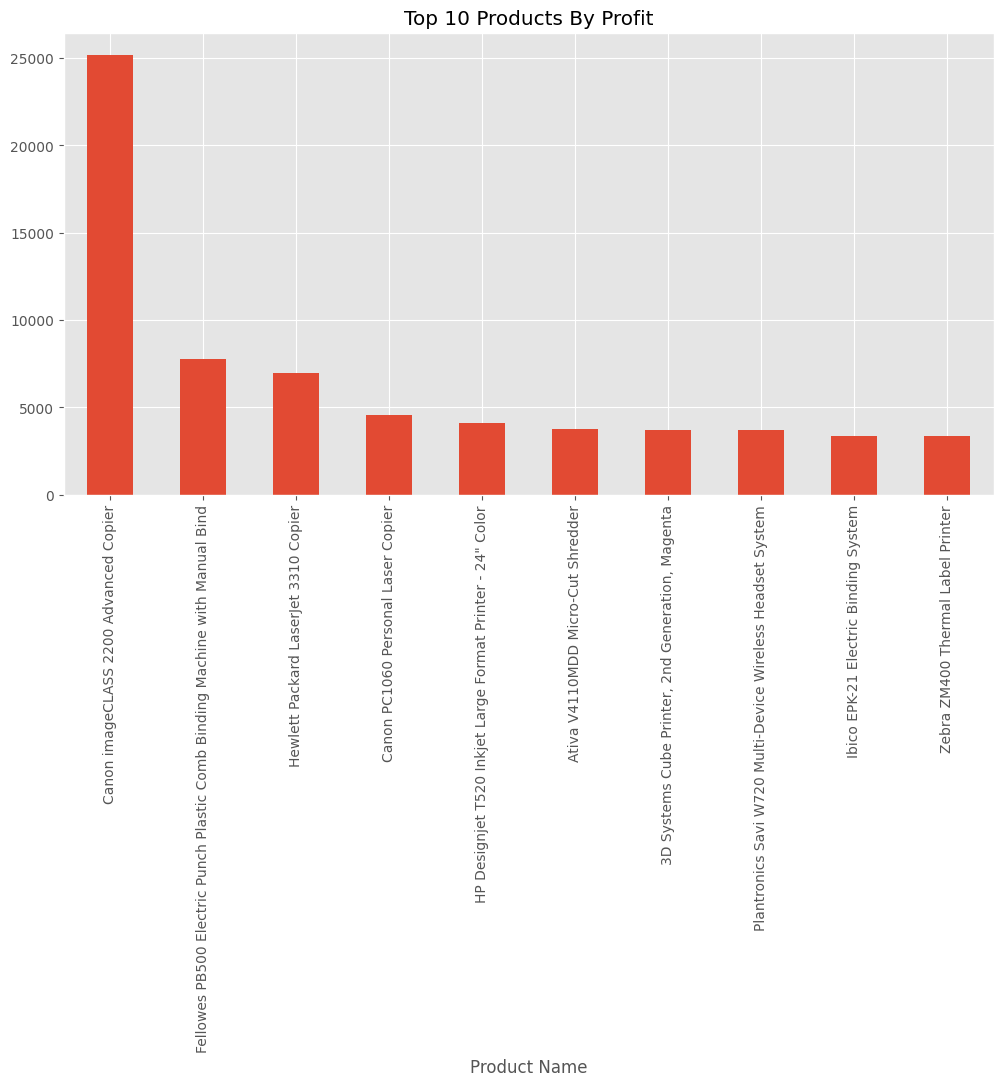

In [62]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_profit_products.plot(kind='bar')

plt.title("Top 10 Products By Profit")
plt.show()

###**Category Wise Sales**

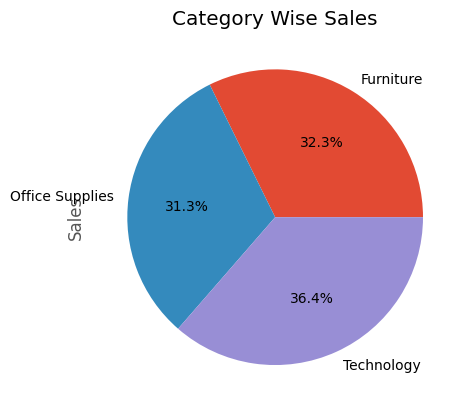

In [63]:
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
)

category_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Category Wise Sales")
plt.show()

###**Category Wise Profit**

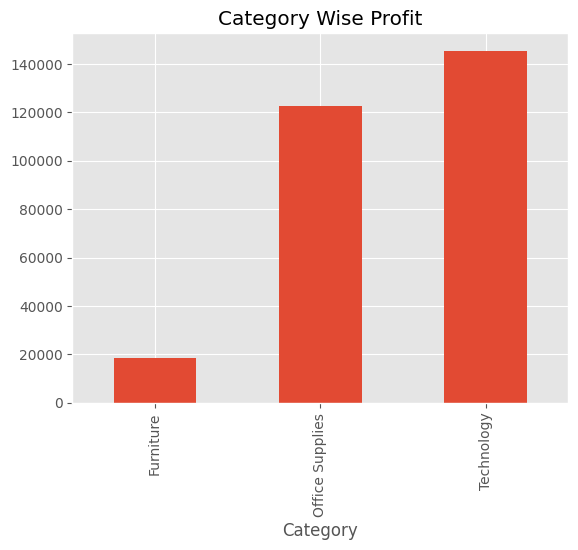

In [64]:
category_profit = (
    df.groupby('Category')['Profit']
    .sum()
)

category_profit.plot(kind='bar')

plt.title("Category Wise Profit")
plt.show()

###**Machine Learning**

In [65]:
features = [
    'Sales',
    'Quantity',
    'Discount',
    'Month',
    'Year',
    'Category',
    'Sub-Category',
    'Region',
    'Segment',
    'Ship Mode'
]

X = df[features]
y = df['Profit']

###**Handle Categorical Variables**

In [66]:
X = pd.get_dummies(X, drop_first=True)

###**Train-Test Split**

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

###**Models**

In [68]:
lr = LinearRegression()

dt = DecisionTreeRegressor(
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

gbr = GradientBoostingRegressor(
    random_state=42
)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

###**Evaluation**

In [69]:
def evaluate_model(model):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    return train_r2, test_r2, rmse

###**Compare Models**

In [70]:
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gbr
}

results = []

for name, model in models.items():

    train_r2, test_r2, rmse = evaluate_model(model)

    results.append([
        name,
        train_r2,
        test_r2,
        rmse
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "RMSE"
    ]
)

results_df.sort_values(
    by="Test R2",
    ascending=False
)

,Model,Train R2,Test R2,RMSE
3,Gradient Boosting,0.964114,0.151714,202.803429
2,Random Forest,0.966301,-0.017303,222.090243
0,Linear Regression,0.489808,-0.645369,282.446284
1,Decision Tree,1.000000,-0.848295,299.357322


###**Business Insights**

In [71]:
print("Most Profitable Category")
print(
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print("\n")

print("Most Profitable Region")
print(
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print("\n")

print("Top 10 Customers By Profit")
print(
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n")

print("Top 10 Loss Making Products")
print(
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

Most Profitable Category
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


Most Profitable Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


Top 10 Customers By Profit
Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


Top 10 Loss Making Products
Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904

###**Discount vs Profit Analysis**

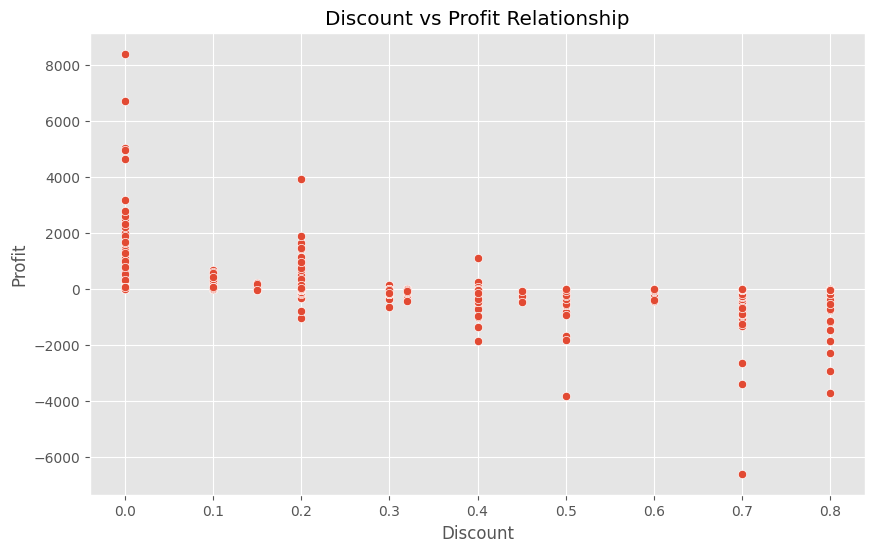

In [72]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

###**Feature Importance**

In [73]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Sales,0.742943
2,Discount,0.209607
12,Sub-Category_Copiers,0.013122
9,Sub-Category_Binders,0.010266
3,Month,0.004622
17,Sub-Category_Machines,0.004415
21,Sub-Category_Supplies,0.003341
30,Ship Mode_Standard Class,0.003046
4,Year,0.002491
22,Sub-Category_Tables,0.001690


###**Feature Importance Chart**

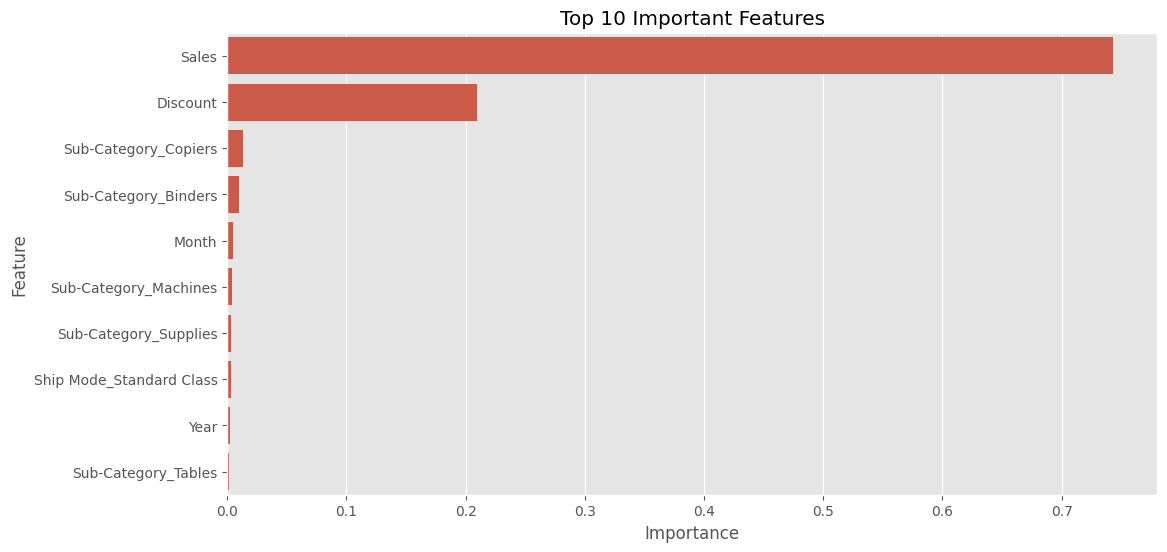

In [74]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

###**Save Model**

In [75]:
import joblib

joblib.dump(
    gbr,
    "profit_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


###**Save Columns**

In [76]:
joblib.dump(
    X.columns.tolist(),
    "model_columns.pkl"
)

print("Columns Saved Successfully")

Columns Saved Successfully
